In [69]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [71]:
import matplotlib.font_manager as fm

# plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [72]:
pd.set_option("display.max_columns", 100)

## step1. 데이터 불러오기 + 병합하기
데이터 병합 어떻게 했냐
- Animal ID를 기준
- 중복 가능성 (한 동물이 여러번 입/퇴소)
- 각 테이블에 DateTime 기준 순번을 매겨서, 같은 순번끼리 매칭되도록 처리

In [73]:
DATA_DIR = r"/content/drive/MyDrive/Matrix/Conference2026"
print("데이터 폴더 내 파일 목록:", os.listdir(DATA_DIR) if os.path.exists(DATA_DIR) else "데이터 폴더 없음 - 먼저 다운로드 필요")

INTAKES_PATH = os.path.join(DATA_DIR, "Austin_Animal_Center_Intakes.csv")
OUTCOMES_PATH = os.path.join(DATA_DIR, "Austin_Animal_Center_Outcomes.csv")

intakes = pd.read_csv(INTAKES_PATH)
outcomes = pd.read_csv(OUTCOMES_PATH)

print("Intakes shape:", intakes.shape)
print("Outcomes shape:", outcomes.shape)

데이터 폴더 내 파일 목록: ['Austin_Animal_Center_Outcomes.csv', 'Austin_Animal_Center_Stray_Map.csv', 'Austin_Animal_Center_Intakes.csv', '.ipynb_checkpoints', 'lgbm_model.pkl', 'lgbm2_model.pkl', 'lgbm3_model.pkl', 'Animal Shelter Analytics.ipynb', 'LightGBM_adoption.ipynb', 'Animal_Shelter_Analytics_updated.ipynb', 'Untitled0.ipynb']
Intakes shape: (124120, 12)
Outcomes shape: (124491, 12)


In [74]:
intakes["DateTime"] = pd.to_datetime(intakes["DateTime"], format="mixed")
outcomes["DateTime"] = pd.to_datetime(outcomes["DateTime"], format="mixed")

intakes = intakes.sort_values(["Animal ID", "DateTime"])
outcomes = outcomes.sort_values(["Animal ID", "DateTime"])

intakes["visit_seq"] = intakes.groupby("Animal ID").cumcount()
outcomes["visit_seq"] = outcomes.groupby("Animal ID").cumcount()

df = pd.merge(
    intakes,
    outcomes,
    on=["Animal ID", "visit_seq"],
    suffixes=("_intake", "_outcome"),
    how="inner",  # 입소-퇴소 기록이 모두 있는 케이스만 사용 (아직 보호소에 있는 동물은 target이 없으므로 제외)
)

print("병합 후 shape:", df.shape)
df.head()

병합 후 shape: (123566, 24)


,Animal ID,Name_intake,DateTime_intake,MonthYear_intake,Found Location,Intake Type,Intake Condition,Animal Type_intake,Sex upon Intake,Age upon Intake,Breed_intake,Color_intake,visit_seq,Name_outcome,DateTime_outcome,MonthYear_outcome,Date of Birth,Outcome Type,Outcome Subtype,Animal Type_outcome,Sex upon Outcome,Age upon Outcome,Breed_outcome,Color_outcome
0,A006100,Scamp,2014-03-07 14:26:00,03/07/2014 02:26:00 PM,8700 Research in Austin (TX),Public Assist,Normal,Dog,Neutered Male,6 years,Spinone Italiano Mix,Yellow/White,0,Scamp,2014-03-08 17:10:00,03/08/2014 05:10:00 PM,07/09/2007,Return to Owner,NaN,Dog,Neutered Male,6 years,Spinone Italiano Mix,Yellow/White
1,A006100,Scamp,2014-12-19 10:21:00,12/19/2014 10:21:00 AM,8700 Research Blvd in Austin (TX),Public Assist,Normal,Dog,Neutered Male,7 years,Spinone Italiano Mix,Yellow/White,1,Scamp,2014-12-20 16:35:00,12/20/2014 04:35:00 PM,07/09/2007,Return to Owner,NaN,Dog,Neutered Male,7 years,Spinone Italiano Mix,Yellow/White
2,A006100,Scamp,2017-12-07 14:07:00,12/07/2017 02:07:00 PM,Colony Creek And Hunters Trace in Austin (TX),Stray,Normal,Dog,Neutered Male,10 years,Spinone Italiano Mix,Yellow/White,2,Scamp,2017-12-07 00:00:00,12/07/2017 12:00:00 AM,07/09/2007,Return to Owner,NaN,Dog,Neutered Male,10 years,Spinone Italiano Mix,Yellow/White
3,A047759,Oreo,2014-04-02 15:55:00,04/02/2014 03:55:00 PM,Austin (TX),Owner Surrender,Normal,Dog,Neutered Male,10 years,Dachshund,Tricolor,0,Oreo,2014-04-07 15:12:00,04/07/2014 03:12:00 PM,04/02/2004,Transfer,Partner,Dog,Neutered Male,10 years,Dachshund,Tricolor
4,A134067,Bandit,2013-11-16 09:02:00,11/16/2013 09:02:00 AM,12034 Research Blvd in Austin (TX),Public Assist,Injured,Dog,Neutered Male,16 years,Shetland Sheepdog,Brown/White,0,Bandit,2013-11-16 11:54:00,11/16/2013 11:54:00 AM,10/16/1997,Return to Owner,NaN,Dog,Neutered Male,16 years,Shetland Sheepdog,Brown/White


## step2. 기본 탐색
데이터 구조 파악

In [75]:
print("\n[컬럼 목록]")
print(df.columns.tolist())


[컬럼 목록]
['Animal ID', 'Name_intake', 'DateTime_intake', 'MonthYear_intake', 'Found Location', 'Intake Type', 'Intake Condition', 'Animal Type_intake', 'Sex upon Intake', 'Age upon Intake', 'Breed_intake', 'Color_intake', 'visit_seq', 'Name_outcome', 'DateTime_outcome', 'MonthYear_outcome', 'Date of Birth', 'Outcome Type', 'Outcome Subtype', 'Animal Type_outcome', 'Sex upon Outcome', 'Age upon Outcome', 'Breed_outcome', 'Color_outcome']


In [76]:
print("\n[데이터 타입]")
print(df.dtypes)


[데이터 타입]
Animal ID                      object
Name_intake                    object
DateTime_intake        datetime64[ns]
MonthYear_intake               object
Found Location                 object
Intake Type                    object
Intake Condition               object
Animal Type_intake             object
Sex upon Intake                object
Age upon Intake                object
Breed_intake                   object
Color_intake                   object
visit_seq                       int64
Name_outcome                   object
DateTime_outcome       datetime64[ns]
MonthYear_outcome              object
Date of Birth                  object
Outcome Type                   object
Outcome Subtype                object
Animal Type_outcome            object
Sex upon Outcome               object
Age upon Outcome               object
Breed_outcome                  object
Color_outcome                  object
dtype: object


In [77]:
print("\n[결측치 개수 및 비율]")
missing = df.isnull().sum().sort_values(ascending=False)
missing_ratio = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"결측치 수": missing, "결측 비율(%)": missing_ratio})
print(missing_table[missing_table["결측치 수"] > 0])


[결측치 개수 및 비율]
                  결측치 수  결측 비율(%)
Outcome Subtype   66751     54.02
Name_intake       38956     31.53
Name_outcome      38956     31.53
Outcome Type         20      0.02
Age upon Outcome      5      0.00
Sex upon Outcome      1      0.00
Sex upon Intake       1      0.00


## step3. target 변수 정의
- **교수님 코멘트 1**: 입양/비입양 이진분류만 쓰면 반환·이송·안락사·기타의 의미가 지나치게 뭉개짐
  - 먼저 `outcome_category`로 다중분류(입양/반환/이송/안락사/기타)를 탐색
  - 그 위에서 이진 타겟 2개를 파생
- **교수님 코멘트 2**: 비입양군 내부 모델과 별개로, 전체 개체 대상 안락사 직접모델도 만들어 비교 → `target_euthanasia_all` 신규 생성
  - `target_adoption`: 1차 모델(입양 가능성)
  - `target_euthanasia_all`: 전체 개체 대상 안락사 위험 직접모델용


[다중분류: outcome_category 분포]
outcome_category
입양     0.443
이송     0.295
반환     0.174
안락사    0.068
기타     0.020
Name: proportion, dtype: float64

[Target1] target_adoption 클래스 비율
target_adoption
0    0.557
1    0.443
Name: proportion, dtype: float64

[Target2] target_euthanasia_all 클래스 비율 (전체 개체 기준)
target_euthanasia_all
0    0.932
1    0.068
Name: proportion, dtype: float64


/tmp/ipykernel_837/2733036722.py:40: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_837/2733036722.py:40: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_837/2733036722.py:40: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_837/2733036722.py:40: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_837/2733036722.py:40: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_837/2733036722.py:40: UserWarning: Glyph 49569 (\N{HANGUL SYLLABLE SONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_837/2733036722.py:40: UserWarning: Glyph 50504 (\N{HANGUL SYLLABLE AN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


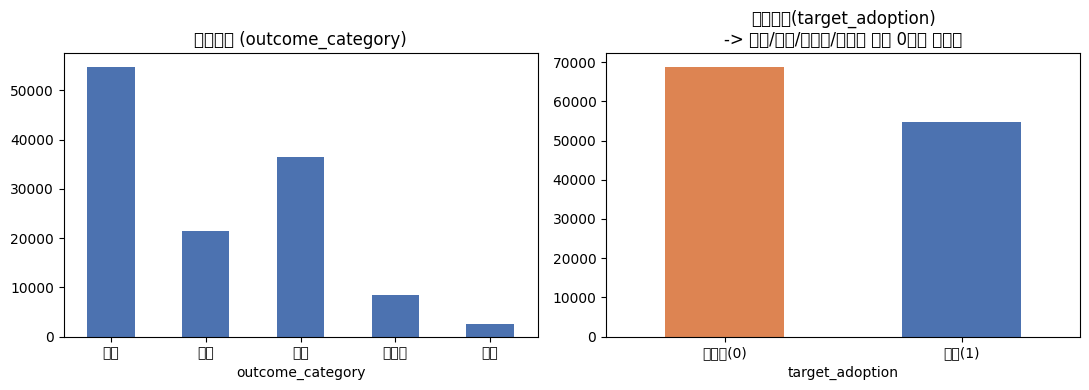


[비입양(target_adoption=0) 내부 구성]
outcome_category
이송     0.530
반환     0.312
안락사    0.121
기타     0.036
Name: proportion, dtype: float64


In [78]:
# Outcome Type -> 입양/반환/이송/안락사/기타 다중분류로 정리
outcome_map = {
    "Adoption": "입양",
    "Return to Owner": "반환",
    "Transfer": "이송",
    "Euthanasia": "안락사",
    # Died, Disposal, Missing, Relocate, Rto-Adopt 등은 전부 '기타'
}

df = df[df["Outcome Type"].notna()]  # target을 만들기 전에 먼저 제거
df["outcome_category"] = df["Outcome Type"].map(outcome_map).fillna("기타")

print("\n[다중분류: outcome_category 분포]")
print(df["outcome_category"].value_counts(normalize=True).round(3))

# 이진 타겟1: 입양 가능성 (1차 모델)
df["target_adoption"] = (df["outcome_category"] == "입양").astype(int)

# 이진 타겟2: 전체 개체 대상 안락사 여부 (직접모델 비교용, 코멘트 2)
df["target_euthanasia_all"] = (df["outcome_category"] == "안락사").astype(int)

print("\n[Target1] target_adoption 클래스 비율")
print(df["target_adoption"].value_counts(normalize=True).round(3))

print("\n[Target2] target_euthanasia_all 클래스 비율 (전체 개체 기준)")
print(df["target_euthanasia_all"].value_counts(normalize=True).round(3))

# 시각화: 다중분류 vs 이진분류 비교 (코멘트 1: "둘 다 살펴보라")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

order = ["입양", "반환", "이송", "안락사", "기타"]
df["outcome_category"].value_counts().reindex(order).plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("다중분류 (outcome_category)")
axes[0].tick_params(axis="x", rotation=0)

df["target_adoption"].value_counts().reindex([0, 1]).plot(kind="bar", ax=axes[1], color=["#DD8452", "#4C72B0"])
axes[1].set_xticklabels(["비입양(0)", "입양(1)"], rotation=0)
axes[1].set_title("이진분류(target_adoption)\n-> 반환/이송/안락사/기타가 모두 0으로 뭉개짐")

plt.tight_layout()
plt.savefig("multiclass_vs_binary.png", dpi=120)
plt.show()

print("\n[비입양(target_adoption=0) 내부 구성]")
print(df.loc[df["target_adoption"] == 0, "outcome_category"].value_counts(normalize=True).round(3))

## step4. 결측치 처리
- 이름 없는 동물들은 "Unknown"으로 대체하기
- Outcome Subtype: 결측 비율이 높고, target 정보 유출(data leakage) 위험이 있으므로
-> 이 프로젝트에서는 아예 사용하지 않고 컬럼에서 제거한다.
- 단, Sex upon Intake/Outcome: 결측이 소수라면 최빈값으로 대체

In [79]:
df["Name_intake"] = df.get("Name_intake", df.get("Name")).fillna("Unknown")

drop_cols = ["Outcome Subtype"]
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

for col in ["Sex upon Intake", "Sex upon Outcome"]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

## step5. 이상치 처리 및 나이 전처리 (수정)
- **교수님 코멘트 4**: 원자료로 복구 불가능한 나이 오류(음수/30세 초과)는 중앙값 대체보다 행 삭제가 더 자연스러움
  - 대체 로직 제거, 삭제로 변경

In [80]:
def age_to_days(age_str):
    # '2 years', '3 months', '1 week', '5 days' 형태의 문자열을 일(day) 단위 숫자로 변환
    if pd.isna(age_str):
        return np.nan
    parts = str(age_str).split()
    if len(parts) != 2:
        return np.nan
    num, unit = parts
    try:
        num = int(num)
    except ValueError:
        return np.nan
    unit = unit.lower()
    if "year" in unit:
        return num * 365
    elif "month" in unit:
        return num * 30
    elif "week" in unit:
        return num * 7
    elif "day" in unit:
        return num
    return np.nan

age_col = "Age upon Intake" if "Age upon Intake" in df.columns else "Age upon Outcome"
df["age_days"] = df[age_col].apply(age_to_days)

print("\n[나이(일) 기초 통계]")
print(df["age_days"].describe())

upper_bound = 30 * 365  # 30살 초과는 이상치로 간주 (도메인 지식 기반 임계값)

# 괄호로 우선순위 명확히 지정 (버그 수정) + 음수도 함께 포함 (버그 수정)
outlier_mask = (df["age_days"] < 0) | (df["age_days"] > upper_bound)
print(f"나이 이상치 개수 (음수 + 30세 초과): {outlier_mask.sum()}")

# 대체(median) 대신 삭제 - 소수(약 7건)이고 원자료 복구가 불가능하므로 (교수님 코멘트 4)
df = df[~outlier_mask].copy()


[나이(일) 기초 통계]
count    123546.000000
mean        750.043741
std        1048.524877
min       -1095.000000
25%          60.000000
50%         365.000000
75%         730.000000
max        9125.000000
Name: age_days, dtype: float64
나이 이상치 개수 (음수 + 30세 초과): 7


## step6. 수치형 변수 처리
- 계절 반영

In [81]:
df["intake_year"] = df["DateTime_intake"].dt.year
df["intake_month"] = df["DateTime_intake"].dt.month
df["intake_weekday"] = df["DateTime_intake"].dt.day_name()

def month_to_season(m):
    if m in [1, 2]:
        return "한겨울"
    elif m in [3, 4]:
        return "봄"
    elif m in [5, 6]:
        return "초여름"
    elif m in [7, 8]:
        return "한여름"
    elif m in [9,10]:
        return "가을"
    else:
        return "초겨울"

df["intake_season"] = df["intake_month"].apply(month_to_season)

In [82]:
# 몇번 반복해서 방문했는지
df["is_repeat_visit"] = (df["visit_seq"] > 0).astype(int)
print(df["visit_seq"].value_counts())

visit_seq
0     110476
1      10014
2       2050
3        592
4        201
5         96
6         48
7         19
8          9
9          4
10         4
11         3
12         2
13         2
14         1
15         1
16         1
17         1
18         1
19         1
20         1
21         1
22         1
23         1
24         1
25         1
26         1
27         1
28         1
29         1
30         1
31         1
32         1
Name: count, dtype: int64


In [83]:
# 체류 기간(보호소에 머문 일수)
df["length_of_stay_days"] = (df["DateTime_outcome"] - df["DateTime_intake"]).dt.days
print(df["length_of_stay_days"].describe(percentiles=[0.5,0.75,0.9,0.95,0.99]))
print("365일 초과:", (df["length_of_stay_days"] > 365).sum())
df = df[df["length_of_stay_days"] >= 0]  # 음수는 제거

count    123539.000000
mean         17.595051
std          47.677313
min       -2274.000000
50%           5.000000
75%          15.000000
90%          49.000000
95%          77.000000
99%         190.000000
max        1521.000000
Name: length_of_stay_days, dtype: float64
365일 초과: 304


## step7. 범주형 변수 처리
- breed, color: 카테고리 수가 너무 많아서 상위 빈도 항목으로 그룹화 (기존 유지)
- **교수님 코멘트 6**: 순종/혼종/주된 품종군/단색/다색 등 의미있는 상위범주로 정리
  → `is_multicolor` 파생변수 추가

In [84]:
# bird 와 livestock 데이터수가 너무 적어서 other로 합침
df["Animal Type_intake"] = df["Animal Type_intake"].replace({
    "Bird": "Other", "Livestock": "Other"
})
df = df[df["Animal Type_intake"].isin(["Dog", "Cat", "Other"])].copy()

In [85]:
print("\nBreed 고유값 개수:", df["Breed_intake"].nunique())
print("Color 고유값 개수:", df["Color_intake"].nunique())

TOP_N = 15

def group_rare_categories(series, top_n=TOP_N):
    top_categories = series.value_counts().nlargest(top_n).index
    return series.apply(lambda x: x if x in top_categories else "Other")

df["breed_grouped"] = group_rare_categories(df["Breed_intake"])
df["color_grouped"] = group_rare_categories(df["Color_intake"])

# 순종/혼종 여부 파생 (Breed 문자열에 'Mix' 포함 여부)
df["is_mixed_breed"] = df["Breed_intake"].str.contains("Mix", case=False, na=False).astype(int)

# 단색/다색 여부 파생 (Color 컬럼이 "Yellow/White"처럼 '/'로 색상을 나열, 코멘트 6)
df["is_multicolor"] = df["Color_intake"].str.contains("/", na=False).astype(int)


Breed 고유값 개수: 2619
Color 고유값 개수: 594


In [86]:
# 이름 유무 여부
df["has_name"] = (df["Name_intake"].ne("Unknown")).astype(int)

In [87]:
# 성별과 중성화 여부로 분리
df["sex"] = df["Sex upon Intake"].map({
    "Intact Male": "Male",
    "Neutered Male": "Male",
    "Intact Female": "Female",
    "Spayed Female": "Female",
    "Unknown": "Unknown"
}).fillna("Unknown")

df["sterilized_status"] = df["Sex upon Intake"].map({
    "Intact Male": "Not Sterilized",
    "Intact Female": "Not Sterilized",
    "Neutered Male": "Sterilized",
    "Spayed Female": "Sterilized",
    "Unknown": "Unknown"
}).fillna("Unknown")

## step8. EDA 2단계 - Target과 주요 변수 간 관계 시각화

In [88]:
animal_summary = (
    df.groupby("Animal Type_intake", observed=True)
      .agg(
          sample_count=("target_adoption", "size"),
          adoption_count=("target_adoption", "sum"),
          adoption_rate=("target_adoption", "mean")
      ).reset_index())

animal_summary["adoption_rate"] = (animal_summary["adoption_rate"] * 100).round(2)

animal_summary

,Animal Type_intake,sample_count,adoption_count,adoption_rate
0,Cat,45943,21030,45.77
1,Dog,69759,32878,47.13
2,Other,7145,733,10.26


/tmp/ipykernel_837/1654146520.py:23: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_837/1654146520.py:23: UserWarning: Glyph 47932 (\N{HANGUL SYLLABLE MUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_837/1654146520.py:23: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_837/1654146520.py:23: UserWarning: Glyph 47448 (\N{HANGUL SYLLABLE RYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_837/1654146520.py:23: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_837/1654146520.py:23: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_837/1654146520.py:23: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  plt.tight_layo

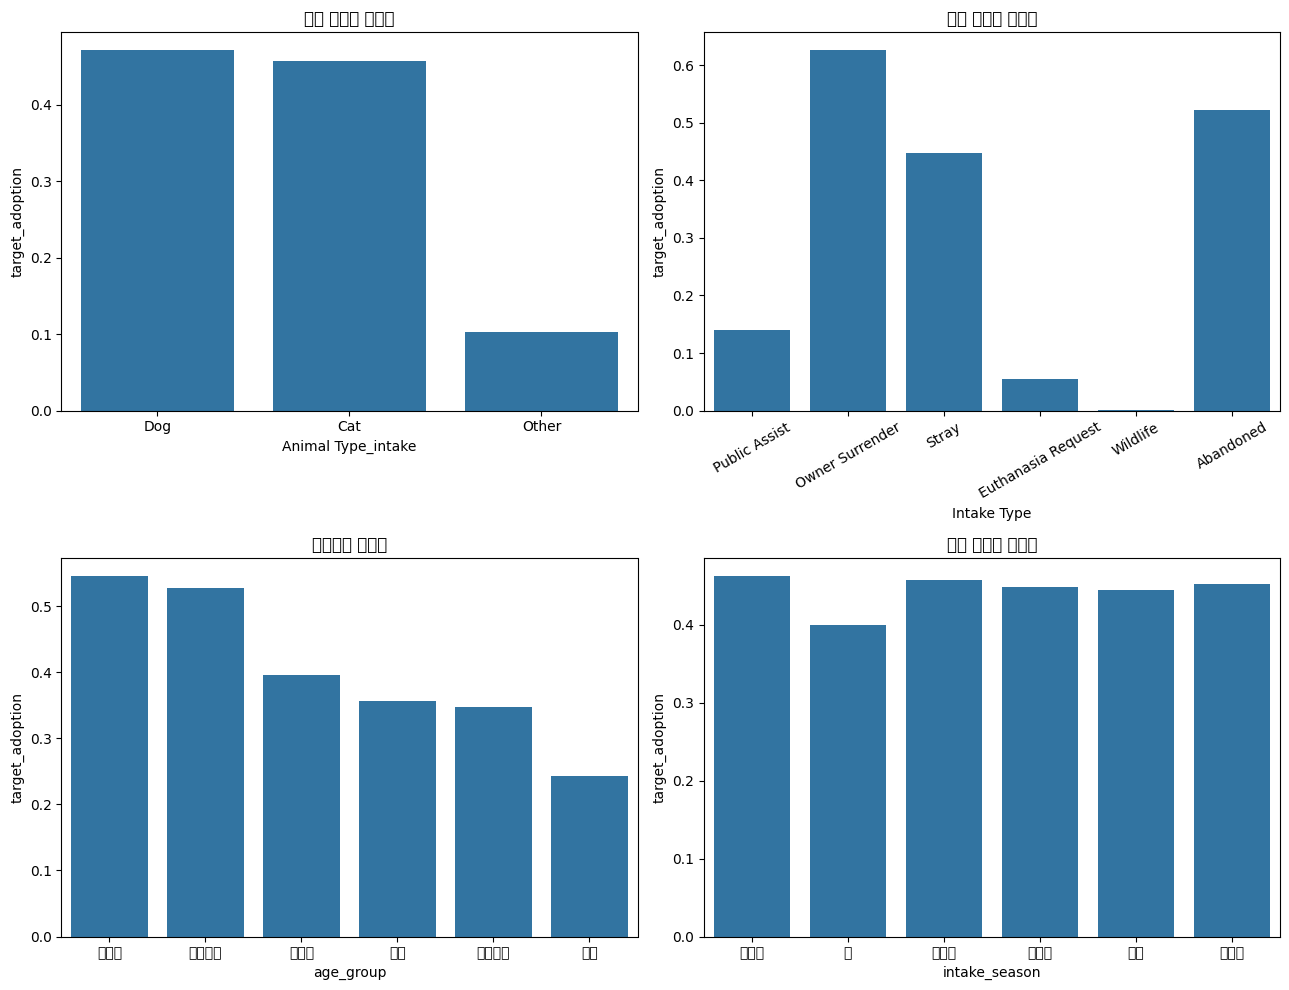

/tmp/ipykernel_837/1654146520.py:32: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_837/1654146520.py:32: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_837/1654146520.py:32: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_837/1654146520.py:32: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_837/1654146520.py:32: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_837/1654146520.py:32: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_837/1654146520.py:32: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/

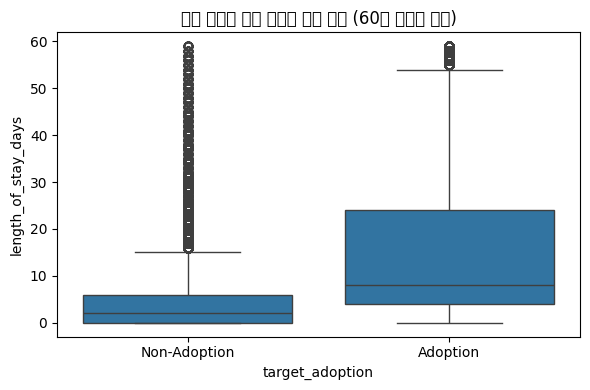

In [89]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# (1) 동물 종류별 입양률
sns.barplot(data=df, x="Animal Type_intake", y="target_adoption", order=["Dog","Cat","Other"], ax=axes[0, 0], errorbar=None)
axes[0, 0].set_title("동물 종류별 입양률")

# (2) 입소 유형별 입양률
sns.barplot(data=df, x="Intake Type", y="target_adoption", ax=axes[0, 1], errorbar=None)
axes[0, 1].set_title("입소 유형별 입양률")
axes[0, 1].tick_params(axis="x", rotation=30)

# (3) 나이(구간화)별 입양률
df["age_group"] = pd.cut(df["age_days"] / 365, bins=[0,0.5,1,3,7,10,30],
                         labels=["유아기","청소년기","청년기","성체","중노년기","고령"],include_lowest=True,right=False)
sns.barplot(data=df, x="age_group", y="target_adoption", ax=axes[1, 0], errorbar=None)
axes[1, 0].set_title("나이대별 입양률")

# (4) 계절별 입양률
sns.barplot(data=df, x="intake_season", y="target_adoption", ax=axes[1, 1], errorbar=None,
            order=["한겨울","봄","초여름","한여름","가을","초겨울"])
axes[1, 1].set_title("입소 계절별 입양률")

plt.tight_layout()
plt.savefig("eda_target_relationships.png", dpi=120)
plt.show()

# 체류 기간과 입양 여부 관계
plt.figure(figsize=(6, 4))
sns.boxplot(data=df[df["length_of_stay_days"] < 60], x="target_adoption", y="length_of_stay_days")
plt.xticks([0, 1], ["Non-Adoption", "Adoption"])
plt.title("입양 여부에 따른 보호소 체류 기간 (60일 미만만 표시)")
plt.tight_layout()
plt.savefig("eda_length_of_stay.png", dpi=120)
plt.show()

## step9. 모델링용 최종 변수 선정 및 인코딩
- `model_df`에 `target_euthanasia_all`도 함께 포함 (코멘트 2, step11에서 사용)

In [90]:
feature_cols = [
    "Animal Type_intake", "sex", "sterilized_status", "Intake Type", "Intake Condition",
    "breed_grouped", "color_grouped", "is_mixed_breed", "has_name", "is_multicolor",
    "age_group", "age_days", "intake_month", "intake_season",
]
feature_cols = [c for c in feature_cols if c in df.columns]

# target_euthanasia_all도 함께 보존 (코멘트 2: step11 2단계 vs 직접모델 비교에서 사용)
model_df = df[feature_cols + ["target_adoption", "target_euthanasia_all"]].copy()

# 버그 수정: age_group(category dtype)을 인코딩 전에 명시적으로 문자열 변환
if "age_group" in model_df.columns:
    model_df["age_group"] = model_df["age_group"].astype(str)

# 범주형 변수 One-Hot Encoding (category dtype까지 포함하도록 안전장치 추가)
categorical_cols = model_df.select_dtypes(include=["object", "category"]).columns.tolist()
model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)

print("\n최종 모델링 데이터 shape:", model_df.shape)
print(model_df.head())


최종 모델링 데이터 shape: (122847, 67)
   is_mixed_breed  has_name  is_multicolor  age_days  intake_month  \
0               1         1              1      2190             3   
1               1         1              1      2555            12   
3               0         1              0      3650             4   
4               0         1              1      5840            11   
5               0         1              1      5475            11   

   target_adoption  target_euthanasia_all  Animal Type_intake_Dog  \
0                0                      0                    True   
1                0                      0                    True   
3                0                      0                    True   
4                0                      0                    True   
5                0                      0                    True   

   Animal Type_intake_Other  sex_Male  sex_Unknown  \
0                     False      True        False   
1                     Fa

## step10. 데이터셋 분할 + 클래스 불균형 처리 준비
- `target_euthanasia_all`도 함께 train/test로 분리 (step11/12에서 사용)

In [91]:
from sklearn.model_selection import GroupShuffleSplit

X = model_df.drop(columns=["target_adoption", "target_euthanasia_all"])
y = model_df["target_adoption"]
y_euth = model_df["target_euthanasia_all"]
groups = df.loc[model_df.index, "Animal ID"]

splitter = GroupShuffleSplit(
    n_splits=1, test_size=0.2, random_state=42
)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]
y_euth_train = y_euth.iloc[train_idx]
y_euth_test = y_euth.iloc[test_idx]

print("\nTrain shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train/Test 중복 Animal ID:", len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])))

# 전처리 완료된 데이터 저장 -> 다음 단계(모델링)에서 바로 불러와서 사용
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)
y_euth_train.to_csv("y_euth_train.csv", index=False)
y_euth_test.to_csv("y_euth_test.csv", index=False)

print("Train target 비율:\n", y_train.value_counts(normalize=True).round(3))
print("Test target 비율:\n", y_test.value_counts(normalize=True).round(3))

# step11/12에서 사용할 train 세트 (X_train + 두 타겟 함께 보관)
train_for_stage_comparison = X_train.copy()
train_for_stage_comparison["target_adoption"] = y_train
train_for_stage_comparison["target_euthanasia_all"] = y_euth_train


Train shape: (98342, 65)  Test shape: (24505, 65)
Train/Test 중복 Animal ID: 0
Train target 비율:
 target_adoption
0    0.556
1    0.444
Name: proportion, dtype: float64
Test target 비율:
 target_adoption
0    0.553
1    0.447
Name: proportion, dtype: float64


## step11. 비입양군 내부 모델 vs 전체개체 대상 직접모델 비교
- **교수님 코멘트 2**: 2단계 구조(비입양군 내부)는 타당하지만, 전체 개체를 대상으로 한
  안락사 여부 직접 모델도 만들어 비교
- train 세트(`X_train`)에서만 수행 (test는 최종 평가 전까지 그대로 보존)
- baseline은 `LogisticRegression(class_weight="balanced")` — 추후 LightGBM 등으로 교체 가능

In [92]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def prepare_stage2_data(model_df, adoption_col="target_adoption", target_col="target_euthanasia_all"):
    """비입양군만 필터링 (기존 2단계 모델용)"""
    subset = model_df[model_df[adoption_col] == 0].copy()
    X = subset.drop(columns=[adoption_col, target_col])
    y = subset[target_col]
    return X, y

def prepare_direct_model_data(model_df, adoption_col="target_adoption", target_col="target_euthanasia_all"):
    """전체 개체 대상 (직접모델용)"""
    X = model_df.drop(columns=[adoption_col, target_col])
    y = model_df[target_col]
    return X, y

def evaluate_euthanasia_model(X, y, model=None, n_splits=5, random_state=42):
    if model is None:
        model = LogisticRegression(max_iter=1000, class_weight="balanced")
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scoring = {"recall": "recall", "pr_auc": "average_precision", "roc_auc": "roc_auc", "f1": "f1"}
    results = cross_validate(model, X, y, cv=cv, scoring=scoring)
    return {m: (results[f"test_{m}"].mean(), results[f"test_{m}"].std()) for m in scoring}

# ---- 수치형 변수 스케일링 (신규) ----
# model_df 만들 때 원-핫 인코딩 안 된 순수 수치형 컬럼만 골라서 스케일링
numeric_cols = [c for c in ["age_days", "intake_month"] if c in feature_cols]

X_stage2, y_stage2 = prepare_stage2_data(train_for_stage_comparison)
X_direct, y_direct = prepare_direct_model_data(train_for_stage_comparison)

scaler_stage2 = StandardScaler()
X_stage2_scaled = X_stage2.copy()
X_stage2_scaled[numeric_cols] = scaler_stage2.fit_transform(X_stage2[numeric_cols])

scaler_direct = StandardScaler()
X_direct_scaled = X_direct.copy()
X_direct_scaled[numeric_cols] = scaler_direct.fit_transform(X_direct[numeric_cols])

print(f"\n[데이터 규모] 2단계(비입양군만): {X_stage2.shape},  직접모델(전체): {X_direct.shape}")

stage2_result = evaluate_euthanasia_model(X_stage2_scaled, y_stage2)
direct_result = evaluate_euthanasia_model(X_direct_scaled, y_direct)

comparison = pd.DataFrame({
    "2단계 모델 (비입양군만)": {k: f"{v[0]:.3f} (+/-{v[1]:.3f})" for k, v in stage2_result.items()},
    "직접 모델 (전체개체)": {k: f"{v[0]:.3f} (+/-{v[1]:.3f})" for k, v in direct_result.items()},
})
print("\n[안락사 예측: 2단계 모델 vs 직접 모델 비교 - baseline LogisticRegression]")
print(comparison)


[데이터 규모] 2단계(비입양군만): (54645, 65),  직접모델(전체): (98342, 65)

[안락사 예측: 2단계 모델 vs 직접 모델 비교 - baseline LogisticRegression]
           2단계 모델 (비입양군만)      직접 모델 (전체개체)
recall   0.800 (+/-0.008)  0.811 (+/-0.016)
pr_auc   0.730 (+/-0.007)  0.712 (+/-0.016)
roc_auc  0.914 (+/-0.003)  0.928 (+/-0.005)
f1       0.654 (+/-0.006)  0.573 (+/-0.007)


In [93]:
from lightgbm import LGBMClassifier

def evaluate_euthanasia_lgbm(X, y, model = None, n_splits=5, random_state=42):
    if model is None:
        model = LGBMClassifier(random_state = random_state, class_weight = "balanced")

    cv = StratifiedKFold(
        n_splits = n_splits,
        shuffle = True,
        random_state = random_state
    )

    scoring = {
        "recall": "recall",
        "pr_auc": "average_precision",
        "roc_auc": "roc_auc",
        "f1": "f1"
    }

    results = cross_validate(
        model,
        X,
        y,
        cv = cv,
        scoring = scoring,
        n_jobs = -1
    )

    return {
        m: (results[f"test_{m}"].mean(), results[f"test_{m}"].std())
        for m in scoring
    }

stage2_result_lgbm = evaluate_euthanasia_lgbm(X_stage2, y_stage2)
direct_result_lgbm = evaluate_euthanasia_lgbm(X_direct, y_direct)

comparison = pd.DataFrame({
    "2단계 모델 (비입양군)": {
        k: f"{v[0]:.3f} (+/-{v[1]:.3f})"
        for k, v in stage2_result.items()
    },
    "직접 모델 (전체개체)": {
        k: f"{v[0]:.3f} (+/-{v[1]:.3f})"
        for k, v in direct_result.items()
    },
})

print("\n[안락사 예측 : 2단계 모델 vs 직접 모델 비교 - LightGBM]")
print(comparison)


[안락사 예측 : 2단계 모델 vs 직접 모델 비교 - LightGBM]
            2단계 모델 (비입양군)      직접 모델 (전체개체)
recall   0.800 (+/-0.008)  0.811 (+/-0.016)
pr_auc   0.730 (+/-0.007)  0.712 (+/-0.016)
roc_auc  0.914 (+/-0.003)  0.928 (+/-0.005)
f1       0.654 (+/-0.006)  0.573 (+/-0.007)


## step12. 클래스 불균형 처리 전략 비교
- **교수님 코멘트 3**: class_weight → 임곗값 조정 → 반복 교차검증 우선 사용,
  오버샘플링(SMOTE)은 반드시 CV 학습 폴드 안에서만 적용
- 안락사 모델은 accuracy보다 recall/PR-AUC 중심으로 평가
- 아래는 2단계 모델(`X_stage2`, `y_stage2`) 기준 비교 예시
- SMOTE 사용 시 사전 설치 필요: `pip install imbalanced-learn`

In [94]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import recall_score, average_precision_score, precision_recall_curve

try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE
    _HAS_IMBLEARN = True
except ImportError:
    _HAS_IMBLEARN = False
    print("imbalanced-learn이 설치되어 있지 않습니다. pip install imbalanced-learn 실행 후 SMOTE 비교가 가능합니다.")

def repeated_cv_with_class_weight(X, y, model=None, n_splits=5, n_repeats=5, random_state=42):
    if model is None:
        model = LogisticRegression(max_iter=1000, class_weight="balanced")
    cv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)
    recalls, pr_aucs = [], []
    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_val)[:, 1]
        preds = model.predict(X_val)
        recalls.append(recall_score(y_val, preds))
        pr_aucs.append(average_precision_score(y_val, proba))
    return {"recall_mean": np.mean(recalls), "recall_std": np.std(recalls),
            "pr_auc_mean": np.mean(pr_aucs), "pr_auc_std": np.std(pr_aucs)}

def find_threshold_for_min_recall(y_true, y_proba, min_recall=0.8):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    precision, recall = precision[:-1], recall[:-1]
    valid = recall >= min_recall
    if not valid.any():
        best_idx = np.argmax(recall)
    else:
        candidate_idx = np.where(valid)[0]
        best_idx = candidate_idx[np.argmax(precision[candidate_idx])]
    return thresholds[best_idx], precision[best_idx], recall[best_idx]

def repeated_cv_with_smote(X, y, model=None, n_splits=5, n_repeats=5, random_state=42):
    if not _HAS_IMBLEARN:
        raise ImportError("imbalanced-learn이 설치되어 있지 않습니다.")
    if model is None:
        model = LogisticRegression(max_iter=1000)
    pipeline = ImbPipeline([("smote", SMOTE(random_state=random_state)), ("model", model)])
    cv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)
    recalls, pr_aucs = [], []
    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        pipeline.fit(X_tr, y_tr)
        proba = pipeline.predict_proba(X_val)[:, 1]
        preds = pipeline.predict(X_val)
        recalls.append(recall_score(y_val, preds))
        pr_aucs.append(average_precision_score(y_val, proba))
    return {"recall_mean": np.mean(recalls), "recall_std": np.std(recalls),
            "pr_auc_mean": np.mean(pr_aucs), "pr_auc_std": np.std(pr_aucs)}

# ---- 아래부터는 X_stage2 대신 X_stage2_scaled 사용 (스케일링 반영) ----
print("\n[전략 1] class_weight='balanced'만 적용 (반복 교차검증)")
print(repeated_cv_with_class_weight(X_stage2_scaled, y_stage2))

print("\n[전략 2] class_weight + 임곗값 조정 (목표 recall >= 0.8)")
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_stage2_scaled, y_stage2)
proba = model.predict_proba(X_stage2_scaled)[:, 1]
threshold, precision, recall = find_threshold_for_min_recall(y_stage2, proba, min_recall=0.8)
print(f"threshold={threshold:.3f}, precision={precision:.3f}, recall={recall:.3f}")

if _HAS_IMBLEARN:
    print("\n[전략 3] SMOTE (CV 학습 폴드 내부에서만 적용)")
    print(repeated_cv_with_smote(X_stage2_scaled, y_stage2))


[전략 1] class_weight='balanced'만 적용 (반복 교차검증)
{'recall_mean': np.float64(0.7981431440294923), 'recall_std': np.float64(0.012936823181920703), 'pr_auc_mean': np.float64(0.7308594011249923), 'pr_auc_std': np.float64(0.01273082265223532)}

[전략 2] class_weight + 임곗값 조정 (목표 recall >= 0.8)
threshold=0.499, precision=0.554, recall=0.800

[전략 3] SMOTE (CV 학습 폴드 내부에서만 적용)
{'recall_mean': np.float64(0.7063152826246736), 'recall_std': np.float64(0.013520138929961312), 'pr_auc_mean': np.float64(0.7015268937689334), 'pr_auc_std': np.float64(0.011450380562764555)}


## 다중분류

In [95]:
# 다중분류 모델링 데이터 생성
model_df_outcome = df[feature_cols].copy()

# 범주형 feature 변수 One-Hot Encoding
categorical_cols = model_df_outcome.select_dtypes(include = ["object","category"]).columns.tolist()
model_df_outcome = pd.get_dummies(model_df_outcome, columns = categorical_cols, drop_first = True)

# target 추가
model_df_outcome["outcome_category"] = df["outcome_category"]

# target 변수 인코딩
mapping = {
    "입양": 0,
    "반환": 1,
    "이송": 2,
    "안락사": 3,
    "기타": 4
}
model_df_outcome["outcome_category"] = model_df_outcome["outcome_category"].map(mapping).astype(int)

In [96]:
from sklearn.model_selection import GroupShuffleSplit

X_outcome = model_df_outcome.drop(columns=["outcome_category"])
y_outcome = model_df_outcome["outcome_category"]
groups = df.loc[model_df_outcome.index, "Animal ID"]

splitter = GroupShuffleSplit(
    n_splits = 1, test_size = 0.2, random_state = 42
)

train_idx, test_idx = next(splitter.split(X_outcome, y_outcome, groups = groups))

X_outcome_train = X_outcome.iloc[train_idx]
X_outcome_test = X_outcome.iloc[test_idx]
y_outcome_train = y_outcome.iloc[train_idx]
y_outcome_test = y_outcome.iloc[test_idx]

In [97]:
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score
)

lgbm_outcome = LGBMClassifier(
    objective="multiclass",
    num_class=5,
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    class_weight="balanced"
)

lgbm_outcome.fit(
    X_outcome_train,
    y_outcome_train
)

y_pred = lgbm_outcome.predict(X_outcome_test)

print("Accuracy :", round(accuracy_score(y_outcome_test, y_pred),4))
print("Balanced Accuracy :", round(balanced_accuracy_score(y_outcome_test, y_pred), 4))
print()

print(classification_report(
    y_outcome_test,
    y_pred,
    target_names=[
        "입양",
        "반환",
        "이송",
        "안락사",
        "기타"
    ]
))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017359 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 182
[LightGBM] [Info] Number of data points in the train set: 98342, number of used features: 64
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Accuracy : 0.6075
Balanced Accuracy : 0.5638

              precision    recall  f1-score   support

          입양       0.69      0.64      0.66     10944
          반환       0.49      0.81      0.61      4224
          이송       0.71      0.44      0.54      7130
         안락사       0.65      0.74  

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49569 (\N{HANGUL SYLLABLE SONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr

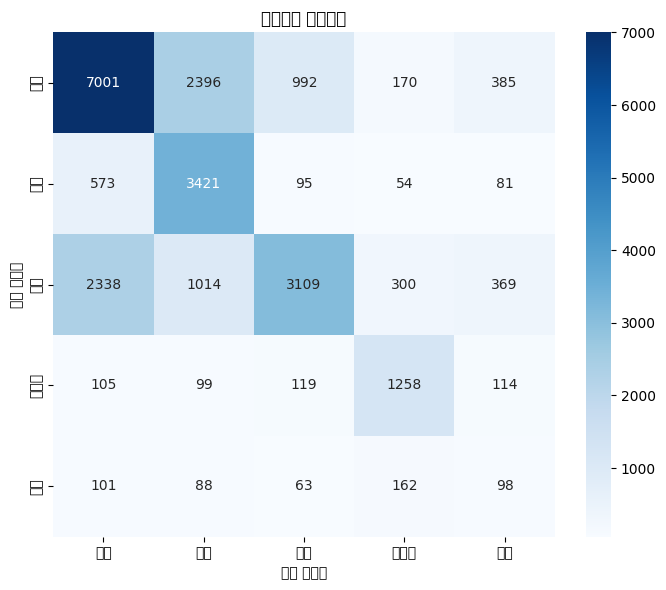

In [98]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_outcome_test, y_pred)

labels = ["입양", "반환", "이송", "안락사", "기타"]

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("예측 클래스")
plt.ylabel("실제 클래스")
plt.title("다중분류 혼동행렬")
plt.tight_layout()
plt.show()